# 03-06 - The Orthomosaic Opens

The photographs of 03-05 went into the software, which is OpenDroneMap and which we call the software from here on, as a folder of files, and came out as one picture of the field in which every point sits where a map would put it. That picture is the orthomosaic, and it is the product the lecture promised the next lecture would open on. This notebook opens it as a file, because the file is where its size, its coordinate system, its resolution and its edges live, and because reading it well is the same skill as reading the satellite tiles of the lecture's third chapter.

We look at the file's structure, count its pixels against the estimate 03-01 made from the field's area and the pixel size, read it through its overviews and through a window, and set one crop at the drone's own resolution beside the same ground in the State's and the federal flights, the last rungs of the resolution ladder. We put the camera positions of 03-05 on the picture, we read what the software reported about its own work, and we end on how a file too large to travel with a repository is read one window at a time.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
reference = json.load(open("data/ground_truth.json"))["p03"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, processed with {flight['processing']['software']}")

this notebook reads the flight preflight-2026-09-17 of 2026-09-17: DJI Mini 3 at 82.5 m, processed with OpenDroneMap


## The product, as a file

The kit ships the orthomosaic around the field at 10 cm, a copy resampled from the software's output by averaging, because the full file is too large for a repository that thirty laptops pull. Open it and ask the questions of 03-01, plus three that a large raster answers and a small one does not: how it is tiled, which overviews it carries, and where it says it has nothing:

In [2]:
src = rasterio.open("data/ortho_10cm.tif")
print("coordinate system ", src.crs)
print("size              ", src.width, "columns by", src.height, "rows, in", src.count, "bands of", src.dtypes[0], "|", src.colorinterp)
print("cell              ", round(src.res[0], 3), src.crs.linear_units)
print("nodata            ", src.nodata, "(none: the file carries a mask instead)")
print("compression       ", src.compression.value if src.compression else None, "| tiles of", src.block_shapes[0], "| overviews", src.overviews(1))
mask = src.read_masks(1) > 0
print(f"valid pixels       {mask.mean():.1%} of the window; the rest is where the model had nothing")
for key in ("source", "licence", "full_resolution_cm", "full_width", "full_height", "note"):
    print(f"  {key:19} {src.tags().get(key)}")

coordinate system  EPSG:32618
size               3323 columns by 2638 rows, in 3 bands of uint8 | (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>)
cell               0.1 metre
nodata             None (none: the file carries a mask instead)
compression        JPEG | tiles of (512, 512) | overviews [2, 4, 8]
valid pixels       66.4% of the window; the rest is where the model had nothing
  source              CEE420 course flight preflight-2026-09-17, DJI Mini 3 at 82.5 m, processed with OpenDroneMap
  licence             CC BY 4.0, CEE420 Urban AI course flight
  full_resolution_cm  3.0
  full_width          11078
  full_height         8794
  note                the orthomosaic around the site resampled to 10 cm by averaging; the full resolution file stays with the instructor, flight.json records its size


Read the coordinate system first. The software placed the model in the satellites' UTM system, EPSG:32618, because the aircraft's receiver speaks WGS 84, while the 3DEP terrain model of 03-04 is in EPSG:26918. The two systems differ on the ground by about a metre and a quarter, and 03-01 showed the trap: the transformation every library here applies between them by default is the null shift, so `to_crs` moves nothing and that metre and a quarter stays inside every comparison until somebody accounts for it. 03-07 and 03-08 do. The bands are red, green and blue, and the file carries a mask rather than a nodata value, so a black pixel outside the model is a masked pixel and not a dark one. The compression is JPEG, which is lossy and right for a picture and wrong for a measurement, which is why the surface model of 03-07 is not compressed this way. And the file is tiled with overviews. A tile is a square block of pixels a reader can fetch on its own, and an overview is a smaller copy of the whole picture stored inside the same file, at a half, a quarter and so on; the list printed above says by how much each one shrinks it. That is exactly the structure of the Sentinel-2 tile the lecture pulled one window from: a reader that wants a corner reads the tiles under the corner, and a reader that wants the whole picture small reads an overview.

## Tens of millions of pixels

The lecture promised tens of millions of pixels. Count them three ways: from the tags, which record the size of the full file the software wrote; from the field's rectangle and the pixel size, the way 03-01 counted the town; and in the shipped copy:

In [3]:
o = reference["ortho"]
full_px = int(src.tags()["full_width"]) * int(src.tags()["full_height"])
gsd_m = float(src.tags()["full_resolution_cm"]) / 100
rect_m2 = reference["plan"]["rect_length_m"] * reference["plan"]["rect_width_m"]
print(f"the full orthomosaic is {src.tags()['full_width']} by {src.tags()['full_height']} pixels of {gsd_m * 100:.2f} cm, {full_px / 1e6:.0f} million pixels, {o['bytes_full'] / 1e6:.0f} MB on disk   reference {o['pixels_full'] / 1e6:.0f} million")
print(f"the field's rectangle alone, {reference['plan']['rect_length_m']} by {reference['plan']['rect_width_m']} m, is {rect_m2 / gsd_m ** 2 / 1e6:.0f} million pixels at that size   reference {o['pixels_over_the_rectangle'] / 1e6:.0f} million")
print(f"the copy in the kit is {src.width} by {src.height} pixels at {src.res[0] * 100:.0f} cm, {src.width * src.height / 1e6:.1f} million pixels, {Path('data/ortho_10cm.tif').stat().st_size / 1e6:.1f} MB")
print(f"both cover the same {src.width * src.res[0]:.0f} by {src.height * src.res[1]:.0f} m, which is the field plus everything else the photographs reached, "
      f"so the full file holds {full_px / (src.width * src.height):.0f} times the pixels of the copy")

the full orthomosaic is 11078 by 8794 pixels of 3.00 cm, 97 million pixels, 144 MB on disk   reference 97 million
the field's rectangle alone, 270.9 by 116.7 m, is 35 million pixels at that size   reference 35 million
the copy in the kit is 3323 by 2638 pixels at 10 cm, 8.8 million pixels, 2.1 MB
both cover the same 332 by 264 m, which is the field plus everything else the photographs reached, so the full file holds 11 times the pixels of the copy


The first line is the promise kept. The second says why the number is what it is, since the field alone at three centimetres is already tens of millions of pixels and the software modelled everything the photographs saw, which is a good deal more than the field. The third and fourth lines are the copy in the kit. It covers exactly the same ground as the full file and differs only in its cell, ten centimetres against three, so its cells are about a third as fine in each direction and it holds about a tenth as many, which is the factor the last line printed. The full file stays on the instructor's machine, and the last section of this notebook is about how a file that size is read when it does live at an address.

## Reading through the overviews

A large raster is never read whole. Here are the two ways to read part of it. The first asks for the entire extent into a small array, which the reader serves from an overview, and the second asks for one window at the file's own resolution, which the reader serves from the tiles under it:

the overview read returned 830 by 659 pixels for the whole extent; the window read returned 400 by 400 pixels for 40 m


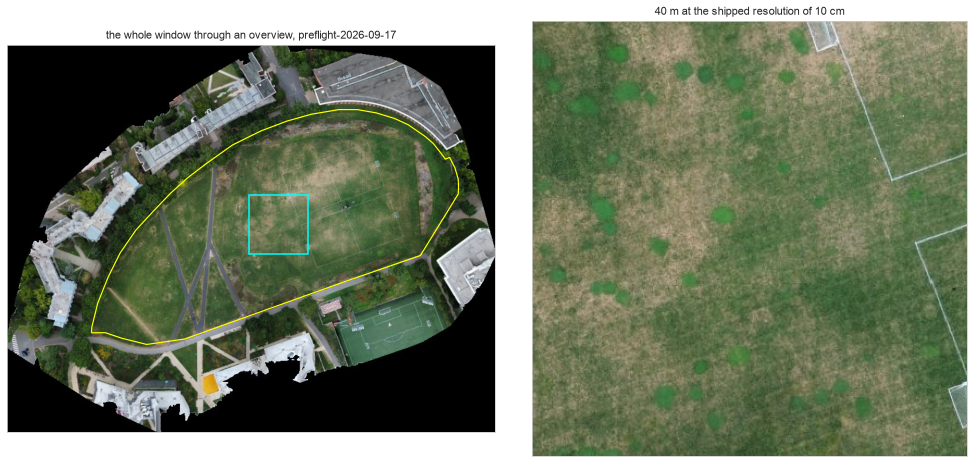

In [4]:
overview = src.read([1, 2, 3], out_shape=(3, src.height // 4, src.width // 4))
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(src.crs)
c = site.geometry.iloc[0].centroid
win = from_bounds(c.x - 20, c.y - 20, c.x + 20, c.y + 20, transform=src.transform)
window = src.read([1, 2, 3], window=win)
extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
wb = src.window_bounds(win)
print(f"the overview read returned {overview.shape[2]} by {overview.shape[1]} pixels for the whole extent; the window read returned {window.shape[2]} by {window.shape[1]} pixels for 40 m")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
axes[0].imshow(np.moveaxis(overview, 0, -1), extent=extent)
site.boundary.plot(ax=axes[0], color="yellow", linewidth=1.2)
axes[0].add_patch(plt.Rectangle((wb[0], wb[1]), wb[2] - wb[0], wb[3] - wb[1], facecolor="none", edgecolor="cyan", linewidth=1.5))
axes[0].set_title(f"the whole window through an overview, {flight['label']}", fontsize=11)
axes[1].imshow(np.moveaxis(window, 0, -1), extent=(wb[0], wb[2], wb[1], wb[3]))
axes[1].set_title("40 m at the shipped resolution of 10 cm", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Two reads and two sizes. The first line says how many pixels came back for the whole extent, far fewer than the file holds, because the reader served them from an overview the file already carries; the second says four hundred rows came back for forty metres, at the file's own 10 cm, from the tiles lying under that square. Neither read touched the rest of the file.

Now the picture itself, and the first thing to notice is what is not in it. Every point sits where the map puts it, so the paths run straight, but the roofs, which the software rendered from a surface it estimated, may show the seams and stretches the lecture warned of, and the edges of the model, where the photographs thinned, fray into the mask. Look also for the shadows and for which side of every tree and wall they fall on. 03-05 printed the sun's elevation for this flight; the lower it stood, the more ground lies in shade and the less the software had to match there.

## The last rungs of the ladder

The kit carries one small piece of the orthomosaic at its full resolution, a window pinned so that every flight of this site crops the same fifty by thirty five metres, so that the last rungs of the resolution ladder can be seen rather than described. Beside it are the same fifty by thirty five metres cut from the State's foot and the federal thirty centimetres, put onto the drone crop's grid with `rioxarray`, which reprojects one raster to match another in one call, and any second flight of the same day that the kit carries:

the crop is 1667 by 1167 pixels of 3.00 cm in EPSG:32618; three coordinate systems had to agree to draw this row


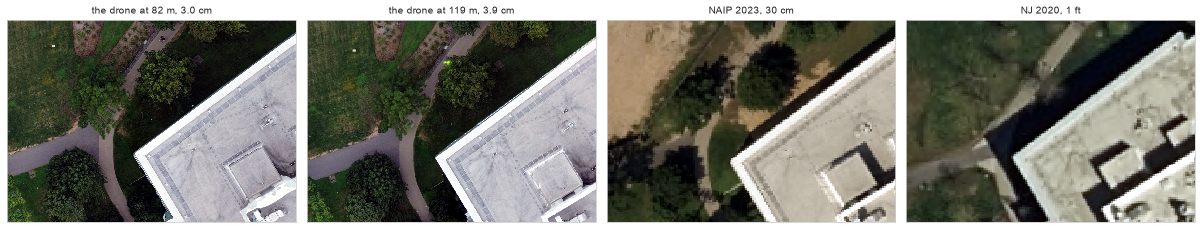

In [5]:
crop = rioxarray.open_rasterio("data/ortho_full_crop.tif")
ladder = {f"the drone at {flight['altitude_agl_m']:.0f} m, {float(crop.rio.resolution()[0]) * 100:.1f} cm": crop}
for name, info in flight.get("other_flights", {}).items():
    other_crop = Path(f"data/ortho_{name}_full_crop.tif")   # built from the label in flight.json, so a flight without one is skipped
    if "orthophoto_full" not in info or not other_crop.exists():
        continue
    crop2 = rioxarray.open_rasterio(other_crop).rio.reproject_match(crop)
    ladder[f"the drone at {info['altitude_agl_m']:.0f} m, {info['orthophoto_full']['res_cm']:.1f} cm"] = crop2
naip = rioxarray.open_rasterio("data/naip_2023_site.tif").sel(band=[1, 2, 3]).rio.reproject_match(crop)     # NAIP writes red, green, blue, near infrared
ladder["NAIP 2023, 30 cm"] = naip
nj = rioxarray.open_rasterio("data/nj2020_site_1ft.tif").sel(band=[2, 3, 4]).rio.reproject_match(crop)       # the State's file writes near infrared first
ladder["NJ 2020, 1 ft"] = nj

fig, axes = plt.subplots(1, len(ladder), figsize=(4.2 * len(ladder), 4.2))
for ax, (title, arr) in zip(axes, ladder.items()):
    a = arr.values[:3].astype("float32")
    lo, hi = np.nanpercentile(a, 1, axis=(1, 2)), np.nanpercentile(a, 99, axis=(1, 2))
    ax.imshow(np.moveaxis(np.clip((a - lo[:, None, None]) / (hi - lo)[:, None, None], 0, 1), 0, -1), interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
print(f"the crop is {crop.rio.width} by {crop.rio.height} pixels of {float(crop.rio.resolution()[0]) * 100:.2f} cm in {crop.rio.crs}; three coordinate systems had to agree to draw this row")

Read the row from right to left, and read each panel's resolution off its own title. The window is pinned, so every flight crops the same ground: a footpath junction at the field's eastern edge, the tree crowns beside it and the corner of a flat roof with its vents. At a foot the roof is a bright shape with a rim and the path a grey band. At thirty centimetres the roof's vents appear and the path has a kerb. At the drone's few centimetres the gravel on the roof, the joints in the pavement and the single shrubs along the path are there. Where a second flight from another height stands beside the first, the lower one has the smaller pixel and you can see it in the gravel and the joints. This is the fifth panel the lecture's figure left empty, and it is now your own.

Three more things are in this row, and none of them is about resolution. The dates differ, and it shows: the federal panel carries the bare earth of the 2023 rebuilding where the other panels have lawn, and the State's leaf-off flight has bare crowns and a long shadow where the drone's summer afternoon has full canopy. That is 03-01's lesson about dates, twice. The roof's edge does not sit in the same place in every panel either. In the federal and the State's pictures the roof leans outward, because those orthophotos were rectified with a terrain model that knows nothing of roofs, exactly as the lecture's relief frame said; in the drone's it stands over its own footprint, because the software used the surface model it had just built. And three coordinate systems had to agree to draw this row, EPSG:32618, EPSG:26918 and the State's feet, which `reproject_match` warped onto one grid. Any offset you see on the ground rather than on the roofs is partly the metre and a quarter of datum that the warp does not apply and partly the receiver's placement of the block, and 03-08 separates the two.

## Where the camera was

The software also writes back where it decided each photograph was taken, after adjusting the whole block, and the kit carries that as a layer. Here are those positions on the orthomosaic:

78 camera positions from the software against 78 photographs, both drawn in EPSG:32618


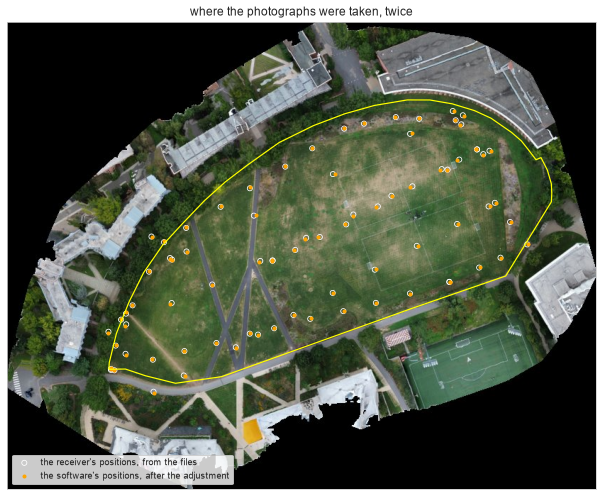

In [6]:
shots = gpd.read_file("data/camera_positions.geojson").to_crs(src.crs)
photos = pd.read_csv("data/photos.csv")
receiver = gpd.GeoDataFrame(photos, geometry=gpd.points_from_xy(photos["easting"], photos["northing"]), crs=photos["crs"].iloc[0]).to_crs(src.crs)
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(np.moveaxis(overview, 0, -1), extent=extent)
site.boundary.plot(ax=ax, color="yellow", linewidth=1.2)
ax.scatter(receiver.geometry.x, receiver.geometry.y, s=26, facecolor="none", edgecolor="white", linewidth=0.8, label="the receiver's positions, from the files")
shots.plot(ax=ax, color="orange", markersize=9, label="the software's positions, after the adjustment")
ax.legend(loc="lower left", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("where the photographs were taken, twice", fontsize=12)
fig.tight_layout()
print(f"{len(shots)} camera positions from the software against {len(photos)} photographs, both drawn in {src.crs}")

Two sets of positions for one flight. The white rings are what the receiver wrote into the files and 03-05 read; the orange dots are where the software concluded the camera must have been for the photographs to fit together, having used the receiver's positions only as a starting guess and a loose anchor to the Earth. Where the two differ by a metre the receiver was wrong by a metre, which is normal; where they differed by much more, the software would have discarded the photograph, and the count printed above tells you whether it did.

## What the software reports

The software writes a report about its own work, and the kit carries its numbers. The ones that matter are how many features it found in each photograph and how many it could match, how many photographs it kept, how far the receiver's positions were from where it put the cameras, and the pixel size it estimated for itself:

In [7]:
report = json.load(open("data/report.json"))
stats = report["stats"]
recon = stats["reconstruction_statistics"]
feat = stats["features_statistics"]["detected_features"]
used = stats["features_statistics"]["reconstructed_features"]
gps = stats["gps_errors"]
proc = stats["odm_processing_statistics"]
ref_proc = reference["report"]["odm_processing_statistics"]

print(f"photographs placed          {recon['reconstructed_shots_count']} of {recon['initial_shots_count']}, in {recon['components']} component(s)")
print(f"points in the sparse cloud  {recon['reconstructed_points_count']:,}")
print(f"features per photograph     {feat['mean']:,.0f} found, {used['mean']:,.0f} of them used, i.e. {used['mean'] / feat['mean']:.0%}")
print(f"reprojection error          {recon['reprojection_error_pixels']:.2f} pixels on average")
print(f"receiver against the cameras {gps['error']['x']:.2f} east, {gps['error']['y']:.2f} north, {gps['error']['z']:.2f} up, average {gps['average_error']:.2f} m")
print(f"the software's own pixel    {proc['average_gsd']:.2f} cm   reference {ref_proc['average_gsd']:.2f} cm")
print(f"processing took             {proc['total_time_human']}   reference {ref_proc['total_time_human']}")

photographs placed          78 of 78, in 1 component(s)
points in the sparse cloud  70,647
features per photograph     5,263 found, 5,040 of them used, i.e. 96%
reprojection error          0.88 pixels on average
receiver against the cameras 0.50 east, 0.37 north, 0.57 up, average 0.79 m
the software's own pixel    3.00 cm   reference 3.00 cm
processing took             20.0m:17.0s   reference 20.0m:17.0s


Read the first three lines before the rest. Every photograph placed, in a single component rather than two, means the software found one block and not two disconnected halves, which is the first thing that goes wrong on a thin flight. The features are the tie points of the lecture's structure from motion frame, distinctive patches the software found in each photograph and looked for in the others; most of what it found it could use, and the few percent it lost are the patches that look like every other patch, which is to say the mown lawn and the deep shade. The reprojection error says how far the average point lands from where the adjusted block says it should, in pixels, and under one pixel is a well behaved block. The receiver's errors are the gap between the white rings and the orange dots above. The software's own pixel size, computed from the block, should agree with 03-05's within a millimetre or two. These are the numbers a report should carry, and none of them says whether the map is in the right place; that needs points the software never saw, which is 03-08.

## The file that did not travel

The full orthomosaic does not travel in this repository and is not published anywhere; it stays on the instructor's machine, and everything above was cut from it. It was written as a Cloud Optimized GeoTIFF, which is a file built so that a reader can fetch one window of it over a network without downloading the rest, exactly as the lecture pulled one window of a Sentinel-2 tile. The cell below is the lane that would do it. If an address is ever filled into `flight.json`, setting `USE_FULL_ORTHO` to `True` opens it, reads a 50 m window at full resolution, reports how much of the file that cost and saves the window. With no address, or left at `False`, nothing here touches a network and the notebook is complete as it stands:

In [8]:
USE_FULL_ORTHO = False
ORTHO_URL = flight.get("release", {}).get("orthophoto_url", "")      # empty on purpose: the full file is not published

full_dir = Path("data/full")
if USE_FULL_ORTHO and ORTHO_URL:
    full_dir.mkdir(exist_ok=True)
    size = reference["ortho"]["bytes_full"]
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"), rasterio.open(ORTHO_URL) as remote:
        cc = site.to_crs(remote.crs).geometry.iloc[0].centroid
        rw = from_bounds(cc.x - 25, cc.y - 25, cc.x + 25, cc.y + 25, transform=remote.transform)
        arr = remote.read(window=rw)
        profile = remote.profile.copy(); profile.update(width=arr.shape[2], height=arr.shape[1], transform=remote.window_transform(rw), driver="GTiff")
        with rasterio.open(full_dir / "ortho_window.tif", "w", **profile) as dst:
            dst.write(arr)
    print(f"read a {arr.shape[2]} by {arr.shape[1]} pixel window of a {size / 1e6:.0f} MB file of {reference['ortho']['pixels_full'] / 1e6:.0f} million pixels; the window is {arr.shape[1] * arr.shape[2] / reference['ortho']['pixels_full']:.2%} of them, and only the tiles under it crossed the network")
elif (full_dir / "ortho_window.tif").exists():
    print("the live lane ran earlier; its window is in data/full/")
else:
    print(f"no address to read from, so nothing was fetched; the 10 cm copy in the kit stands for the full file, "
          f"which is {reference['ortho']['bytes_full'] / 1e6:.0f} MB of {reference['ortho']['pixels_full'] / 1e6:.0f} million pixels")

no address to read from, so nothing was fetched; the 10 cm copy in the kit stands for the full file, which is 144 MB of 97 million pixels


Whichever line printed, nothing went wrong. The lane has three branches: it fetches a window when an address exists and you have asked for it, it reports an earlier window if one is already saved, and otherwise it says what the file would have been and leaves the network alone. The point of the section is the shape of the file rather than the fetch, and you have that either way.

## Your turn

Two questions about the picture you have. First, how much of Poe Field did the model cover? Use the mask and the field polygon to compute the share of the field's cells that hold a valid pixel, and compare it with the reference. Second, count something on the full resolution crop that a satellite could never count, and write down the number and what it is; the lecture's cliffhanger was that next week we teach a machine to do that counting.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. mask is the valid mask of the shipped orthomosaic and site is the field in its coordinate system.
#
# from rasterio.features import geometry_mask
# inside = geometry_mask([site.geometry.iloc[0]], out_shape=___, transform=___, invert=True)   # True inside the field
# print(f"{mask[___].mean():.1%} of the field holds a valid pixel   reference {reference['ortho']['valid_share_of_site']:.1%}")
#
# fig, ax = plt.subplots(figsize=(10, 7))
# ax.imshow(np.moveaxis(crop.values[:3], 0, -1))
# ax.set_title("count something here")

## Check your understanding

1. The orthomosaic is in EPSG:32618 and the 3DEP terrain model in EPSG:26918. Name the two things you must settle before subtracting one from the other, one of which this notebook names and the other of which 03-04 did.
2. The file carries a mask rather than a nodata value and JPEG compression rather than none. For each, say why that choice is right for a picture and would be wrong for the surface model.
3. The full file holds about eleven times the pixels of the shipped copy. Describe, in one sentence each, the two reads that make a file that size usable without downloading it.
4. The software reports how far the receiver's positions were from the adjusted cameras, and it is about a metre. Does that number tell you how accurate the orthomosaic is? Say what it does tell you and what it does not.

## Where we are

You can open a large raster and read its tiles, its overviews, its mask and its compression, and you know why each is what it is. You have counted the pixels of your own flight three ways, read the file through an overview and through a window, and set the drone's resolution beside the State's and the federal flights on one grid. You have seen the software's positions beside the receiver's, read the report's numbers and know what they leave out, and you know how a window of a file too large to download is fetched when it has an address.

The habit worth keeping: ask a large raster how it is tiled and what overviews it carries before you read it, and read a window or an overview, never the whole.

In 03-07 we subtract the terrain from the surface and get the height of things, once the two agree on where zero is.

## Further resources

Nothing in this course requires anything below.

The Cloud Optimized GeoTIFF specification explains the tiles, the overviews and the byte ranges that make a window read possible: https://cogeo.org/. Rasterio's documentation covers windowed reading and reading through overviews: https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html, and `rioxarray` documents `reproject_match`: https://corteva.github.io/rioxarray/stable/examples/reproject_match.html

OpenDroneMap's documentation describes the orthomosaic, which it calls the orthophoto, the report, and every option the processing used: https://docs.opendronemap.org/arguments/

The orthomosaic, the camera positions and the report are the course's own flight, published under CC BY 4.0. The 2023 aerial photograph is USDA NAIP, public domain, and the 2020 orthophoto a public record of the State of New Jersey. The outline of Poe Field is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The share of the field with a valid pixel, from the file itself so that the cell stands on its own:

```python
import json
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask

reference = json.load(open("data/ground_truth.json"))["p03"]
with rasterio.open("data/ortho_10cm.tif") as src:
    mask = src.read_masks(1) > 0
    site = gpd.read_file("data/site.gpkg", layer="site").to_crs(src.crs)
    inside = ~geometry_mask([site.geometry.iloc[0]], out_shape=mask.shape, transform=src.transform)
print(f"{mask[inside].mean():.1%} of the field holds a valid pixel   reference {reference['ortho']['valid_share_of_site']:.1%}")
```

The second question has no code. Pick the crop's most countable thing, the parking bays, the manhole covers, the court's lines or the people, count it, and keep the number: in P04 you will hand a machine the same picture and see whether it agrees with you.